# Experiments 
In this notebook we'll develop some experiments about the performance of LSTM architecture vs TimesFM.

__Content__:
1. Load data and preparate for training
2. Train LSTM
3. Train TimesFM
4. Save results and discussion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from matplotlib.ticker import MaxNLocator

loss_folder = 'C:/Users/criju/Documents/Codigos Tesis/loss_plots_3'
os.makedirs(loss_folder, exist_ok=True)

es_cb = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

## 1. Train LSTM 
Now we'll train LSTM with 3 windows sizes (7,14,21), 2 different forecast horizon (15,30) and for each interval we add the previous one.

In [2]:
# Load the dataset
df =  pd.read_csv('C:/Users/criju/Documents/Codigos Tesis/data/serie.csv')
df['Fecha'] = pd.to_datetime(df['Fecha'])

# Functions for data processing and model building
def create_intervals(df):
    """
    Divide un DataFrame en 8 intervalos regulares basados en la columna 'Fecha',
    grafica los datos y devuelve los intervalos.
    """
    fecha_min = df['Fecha'].min()
    fecha_max = df['Fecha'].max()
    bins = pd.date_range(start=fecha_min, end=fecha_max, periods=9)  # 9 puntos para generar 8 intervalos
    df['Intervalo'] = pd.cut(df['Fecha'], bins=bins, include_lowest=True, right=False)
    intervalos_ordenados = sorted(df['Intervalo'].dropna().unique(), key=lambda x: x.left)
    return intervalos_ordenados

def build_lstm_model(window_size):
    model = Sequential([
        LSTM(32, activation='relu', input_shape=(window_size, 1), dropout=0.2),
        Dense(32),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model


def create_windows(data, window_size):
    """
    Genera secuencias (ventanas) a partir de la serie de tiempo.
    
    Args:
        data (np.array): Valores escalados de la serie.
        window_size (int): Longitud de la ventana.
        
    Returns:
        tuple: Arrays (x, y) donde x son las secuencias y y el valor a predecir.
    """
    x = []
    y = []
    for i in range(len(data) - window_size):
        x.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(x), np.array(y)

def smape(y_true, y_pred, eps=1e-8):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return 100 * np.mean(numerator / (denominator + eps))

In [3]:
# Review the numbers of parameters of LSTM
model = build_lstm_model(window_size=7)
model.summary()

c:\Users\criju\.conda\envs\ts\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,441 (21.25 KB)

 Trainable params: 5,441 (21.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train for windows size = 7


Iteración 1: Mejor época = 17, Loss = 0.0636
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Acumulando intervalos 1 a 1: MAE = 112.87, MSE = 25574.06


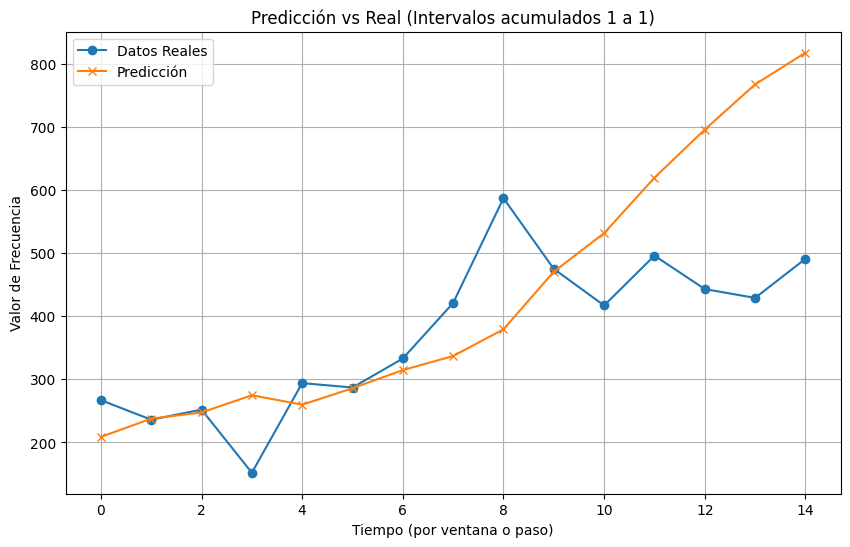

Iteración 2: Mejor época = 5, Loss = 0.0624
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 2: MAE = 109.59, MSE = 19310.39


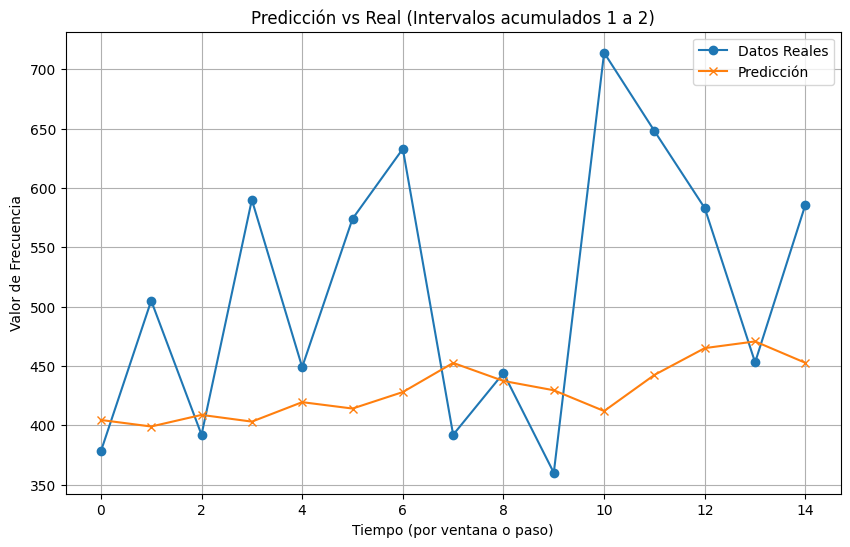

Iteración 3: Mejor época = 14, Loss = 0.0834
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 3: MAE = 232.45, MSE = 92870.73


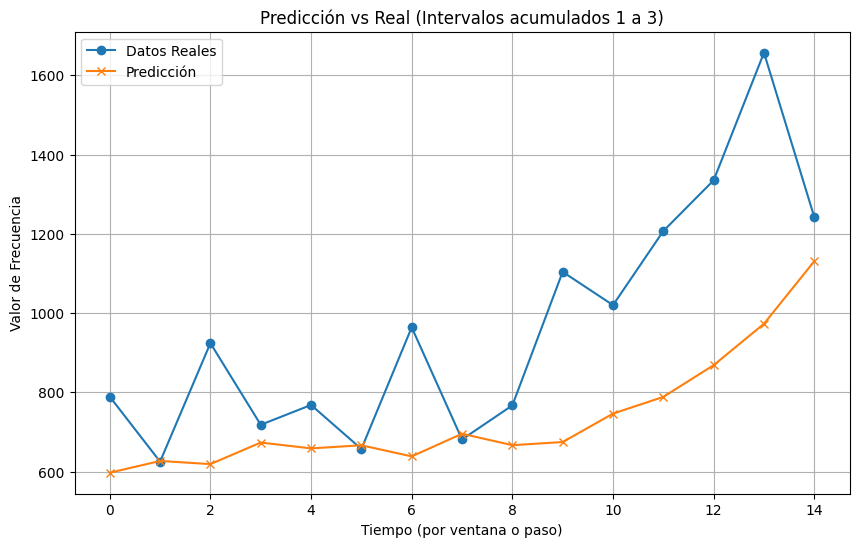

Iteración 4: Mejor época = 12, Loss = 0.2514
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 4: MAE = 56.84, MSE = 3268.48


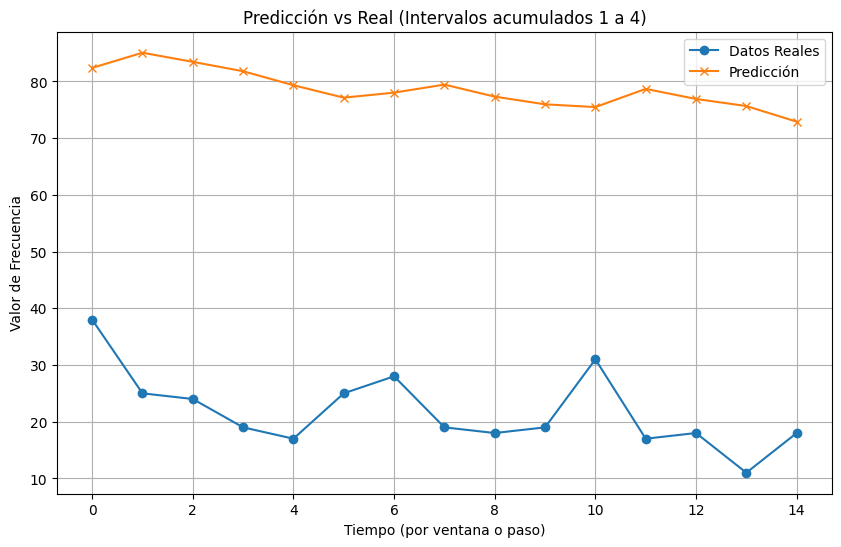

Iteración 5: Mejor época = 6, Loss = 0.2369
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 5: MAE = 96.32, MSE = 13112.86


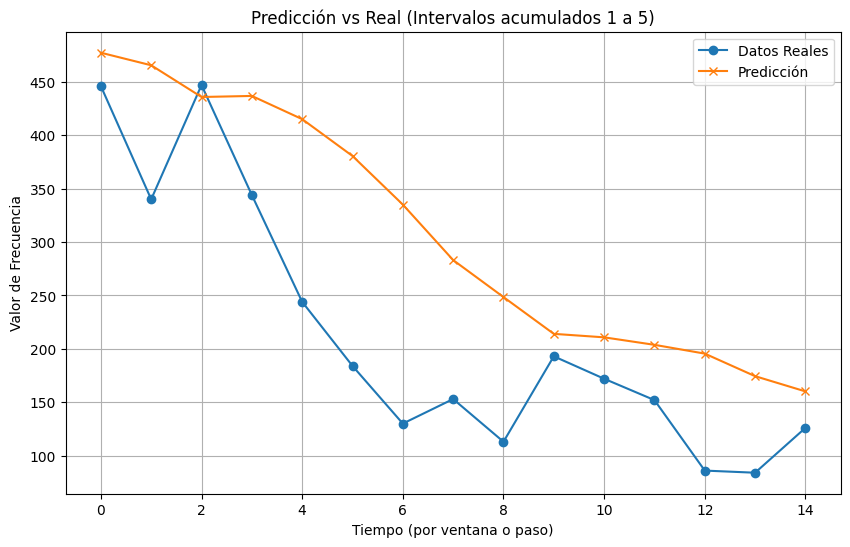

Iteración 6: Mejor época = 5, Loss = 0.2673
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 6: MAE = 41.95, MSE = 2110.38


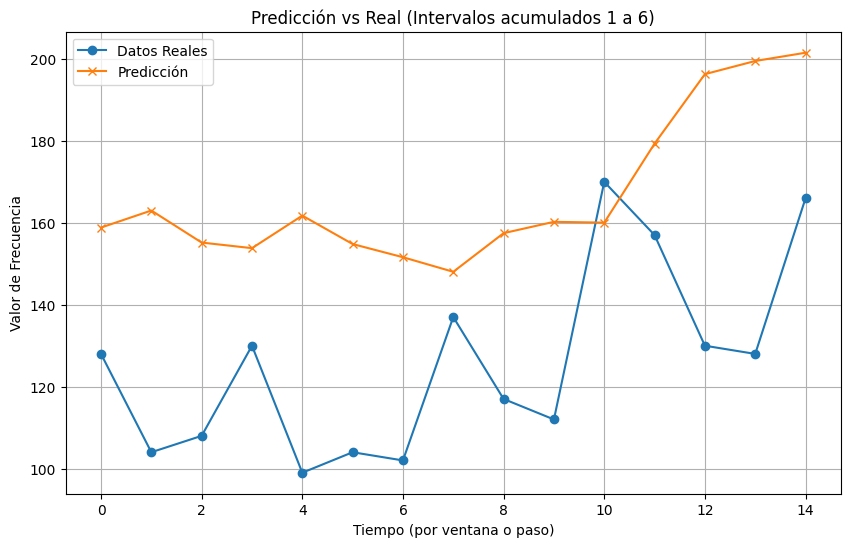

Iteración 7: Mejor época = 9, Loss = 0.2930
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 7: MAE = 13.29, MSE = 251.19


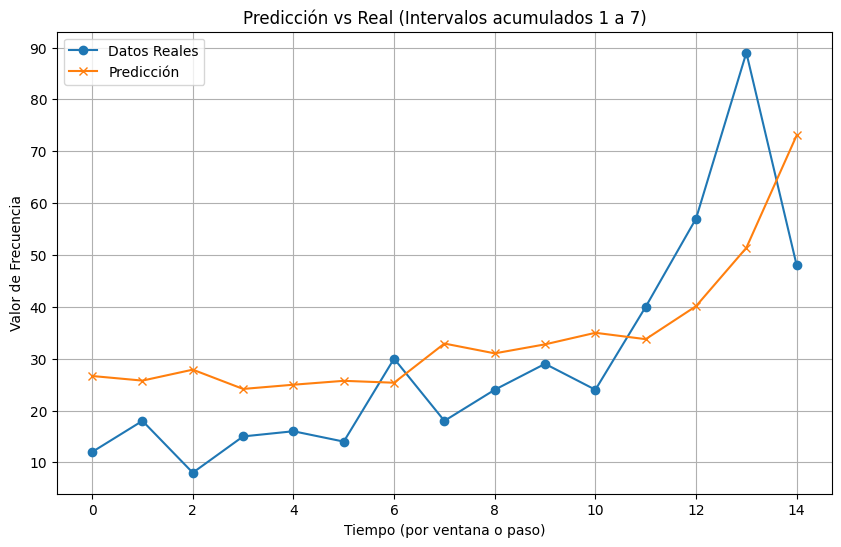

Iteración 8: Mejor época = 5, Loss = 0.2671
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 8: MAE = 13.63, MSE = 197.37


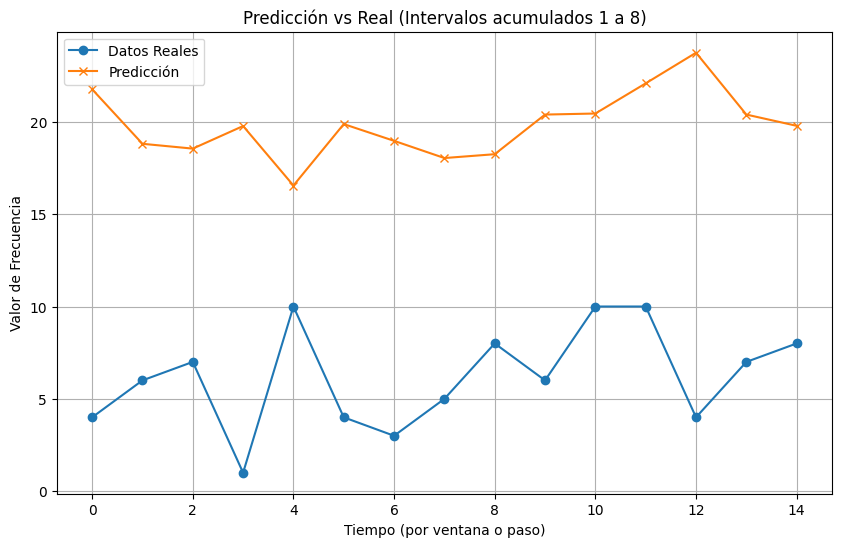


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1  112.869640  25574.062679   24.421346
1      Intervalos 1 a 2  109.590769  19310.385070   21.778479
2      Intervalos 1 a 3  232.447453  92870.729988   24.833406
3      Intervalos 1 a 4   56.836717   3268.481216  114.525092
4      Intervalos 1 a 5   96.320063  13112.860420   42.664423
5      Intervalos 1 a 6   41.954943   2110.376966   29.363355
6      Intervalos 1 a 7   13.285825    251.192814   44.581360
7      Intervalos 1 a 8   13.627660    197.370087  107.282272


In [4]:
# Parameters
WINDOW_SIZE = 7  
HORIZONTE = 15 
EPOCHS = 50 
BATCH_SIZE = 16     
intervalos_ordenados = create_intervals(df)

resultados = [] 

# Inicializamos el escalador (se ajustará en cada iteración)
# scaler = MinMaxScaler(feature_range=(0, 1))

scaler = RobustScaler()

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"7_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_6/lstm_7_15.csv', index=False)

Iteración 1: Mejor época = 13, Loss = 0.0003
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Acumulando intervalos 1 a 1: MAE = 141.04, MSE = 28524.13


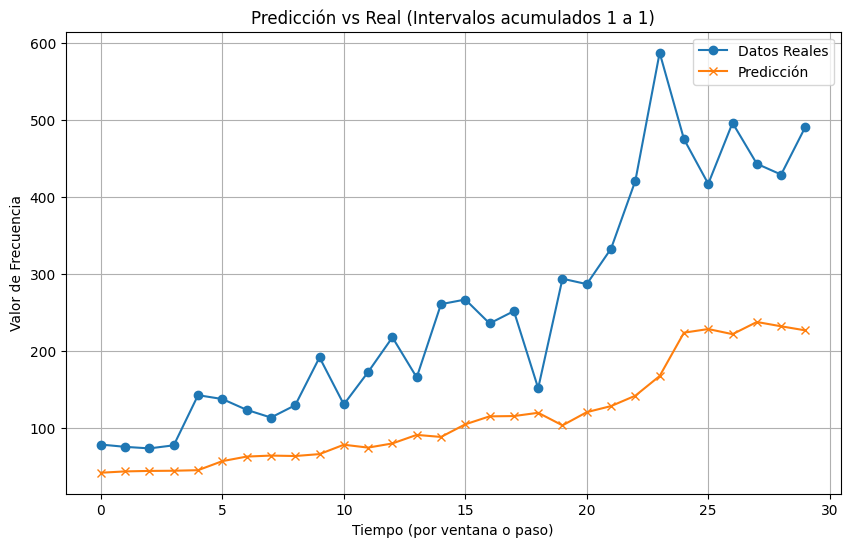

Iteración 2: Mejor época = 14, Loss = 0.0217
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Acumulando intervalos 1 a 2: MAE = 110.44, MSE = 20617.05


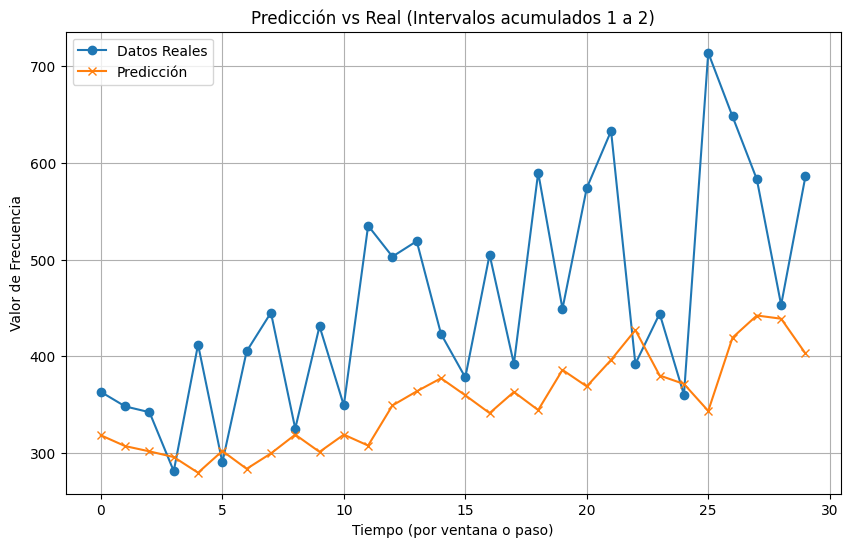

Iteración 3: Mejor época = 30, Loss = 0.0056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 3: MAE = 246.20, MSE = 95690.48


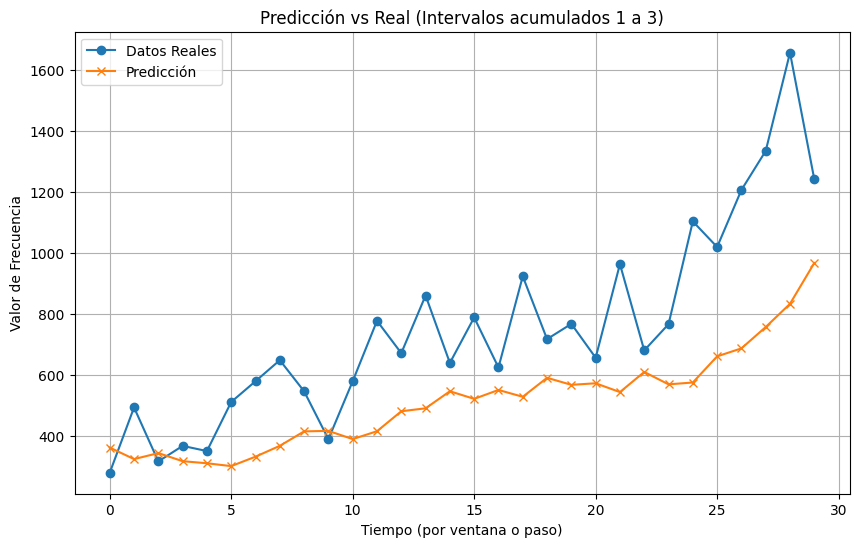

Iteración 4: Mejor época = 2, Loss = 0.0085
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 4: MAE = 160.12, MSE = 25676.90


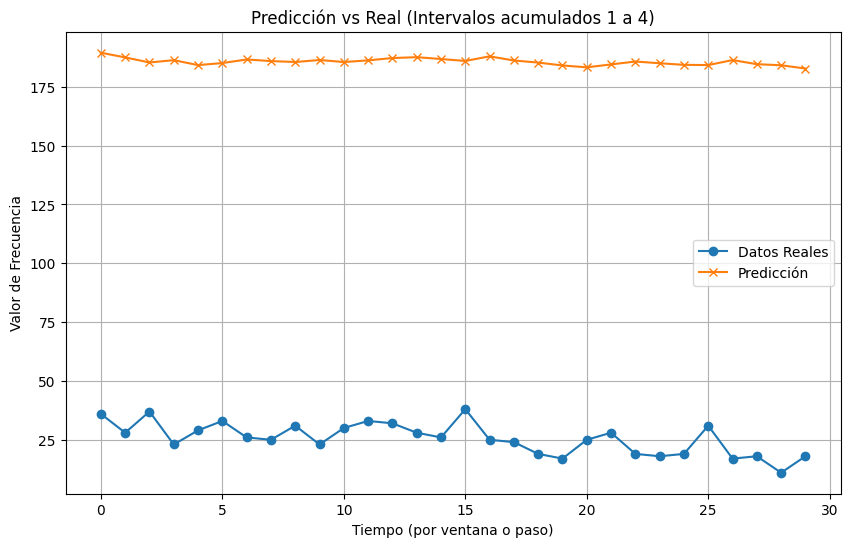

Iteración 5: Mejor época = 5, Loss = 0.0088
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 5: MAE = 76.99, MSE = 11945.63


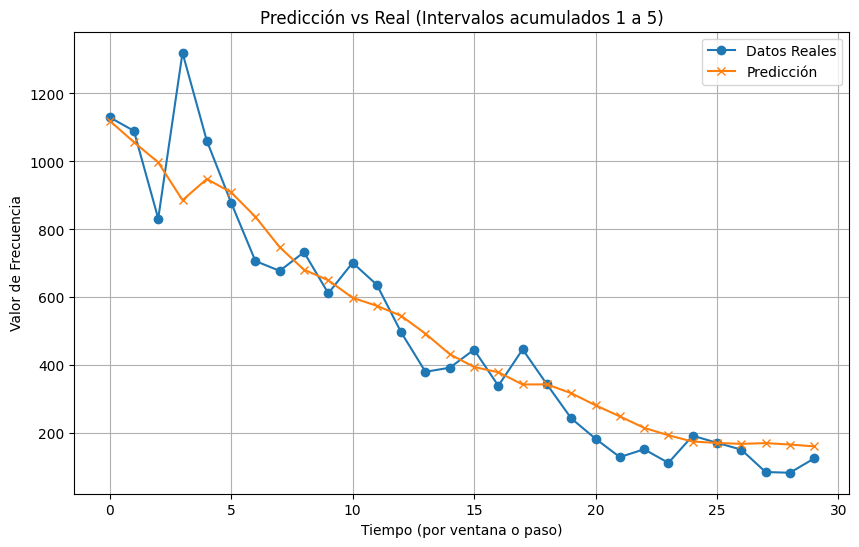

Iteración 6: Mejor época = 16, Loss = 0.0083
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 6: MAE = 19.68, MSE = 503.94


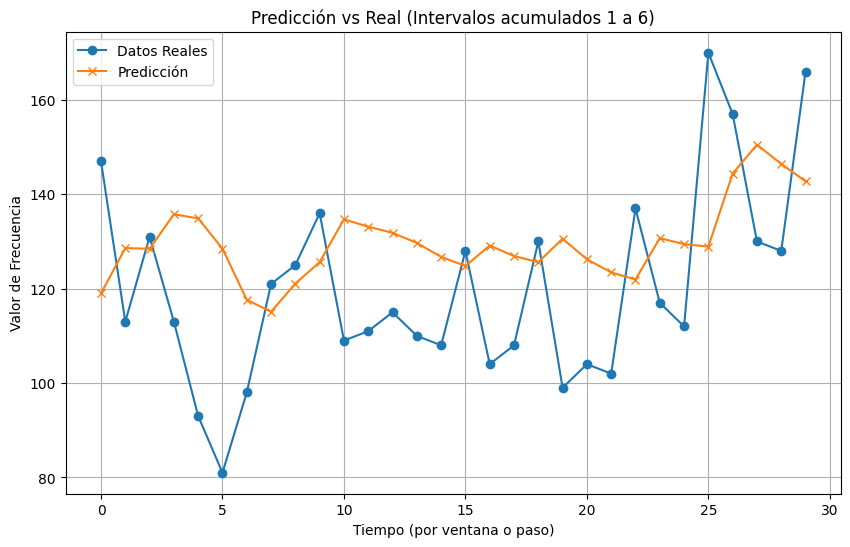

Iteración 7: Mejor época = 7, Loss = 0.0068
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 7: MAE = 141.54, MSE = 21551.50


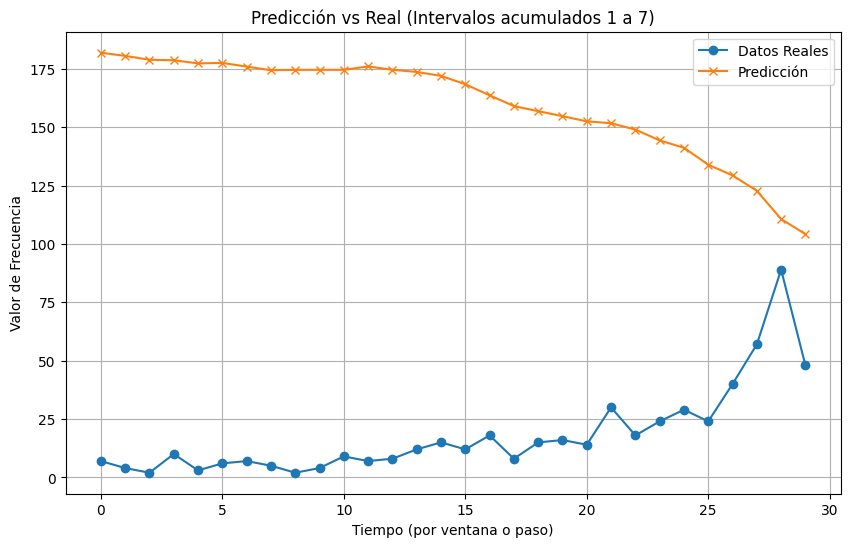

Iteración 8: Mejor época = 8, Loss = 0.0061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 8: MAE = 136.23, MSE = 18595.46


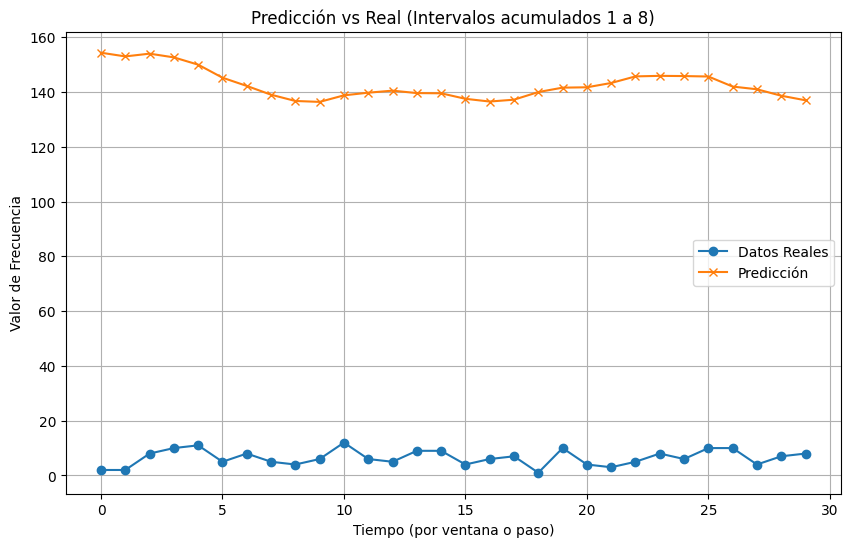


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1  141.041446  28524.127069   73.043031
1      Intervalos 1 a 2  110.437648  20617.048479   25.345789
2      Intervalos 1 a 3  246.199127  95690.479461   35.780287
3      Intervalos 1 a 4  160.118855  25676.899648  151.965600
4      Intervalos 1 a 5   76.987307  11945.632829   21.063400
5      Intervalos 1 a 6   19.675375    503.941815   16.052070
6      Intervalos 1 a 7  141.540541  21551.497181  158.961776
7      Intervalos 1 a 8  136.229912  18595.456569  182.689785


In [5]:
# Parameters
WINDOW_SIZE = 7 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"7_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_6/lstm_7_30.csv', index=False)

### Train for windows size = 14

Iteración 1: Mejor época = 15, Loss = 0.0008
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Acumulando intervalos 1 a 1: MAE = 83.37, MSE = 10936.03


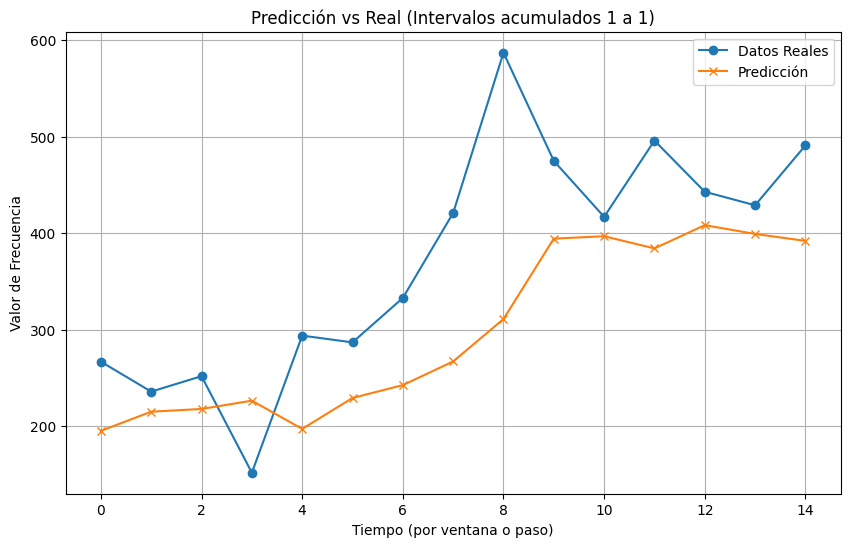

Iteración 2: Mejor época = 6, Loss = 0.0211
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 2: MAE = 124.77, MSE = 26252.72


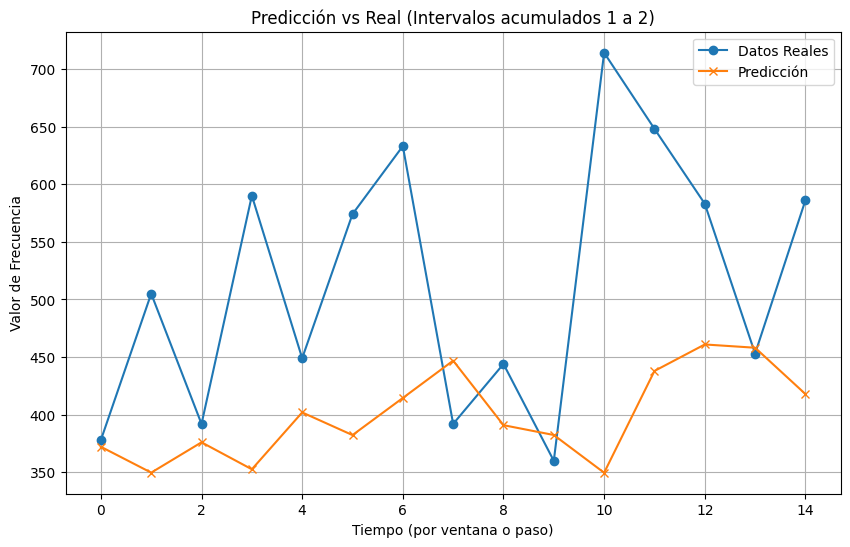

Iteración 3: Mejor época = 7, Loss = 0.0061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 3: MAE = 307.46, MSE = 138491.17


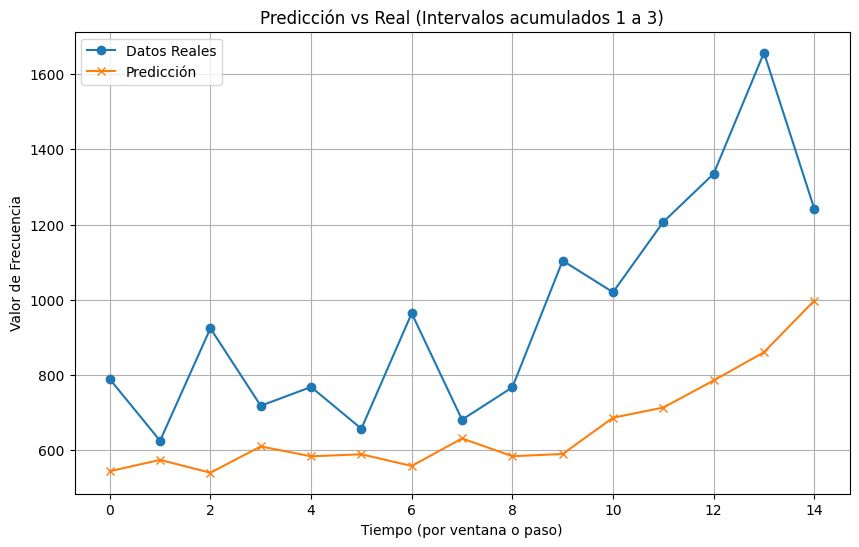

Iteración 4: Mejor época = 2, Loss = 0.0089
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 4: MAE = 58.92, MSE = 3800.30


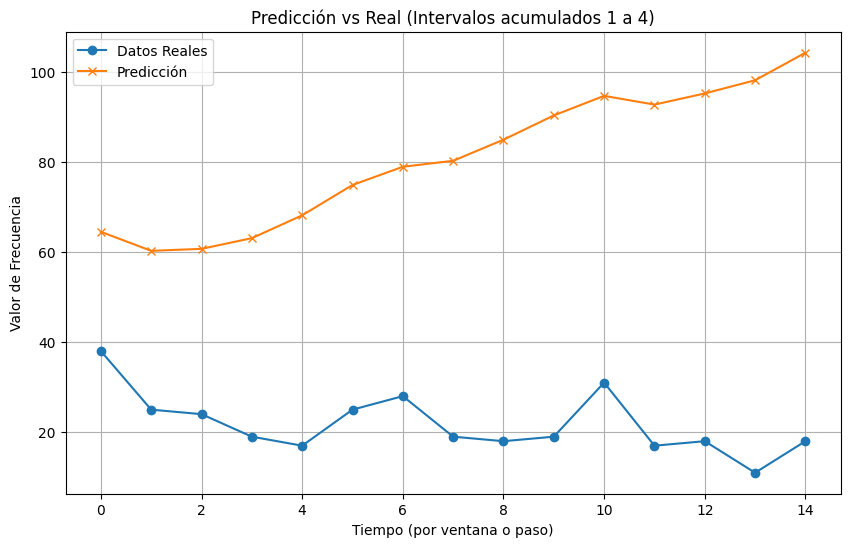

Iteración 5: Mejor época = 10, Loss = 0.0079
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 5: MAE = 58.07, MSE = 4745.63


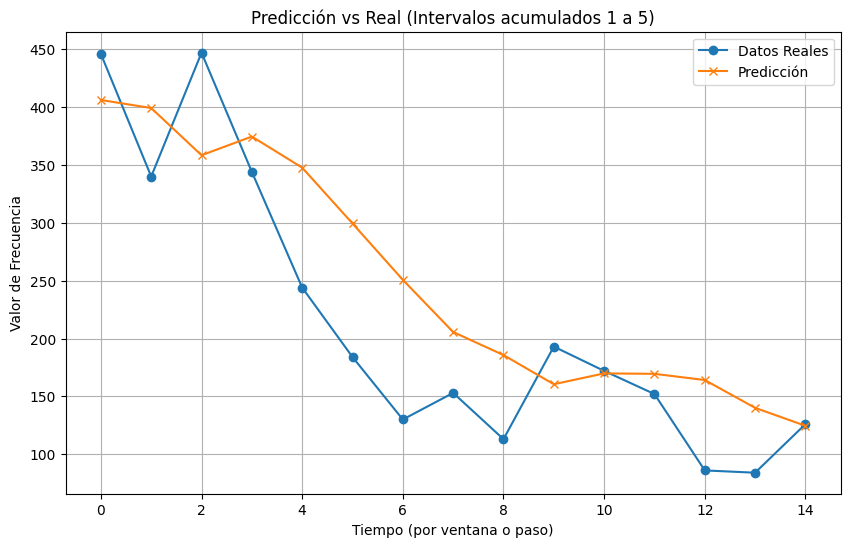

Iteración 6: Mejor época = 1, Loss = 0.0071
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 6: MAE = 57.92, MSE = 3775.83


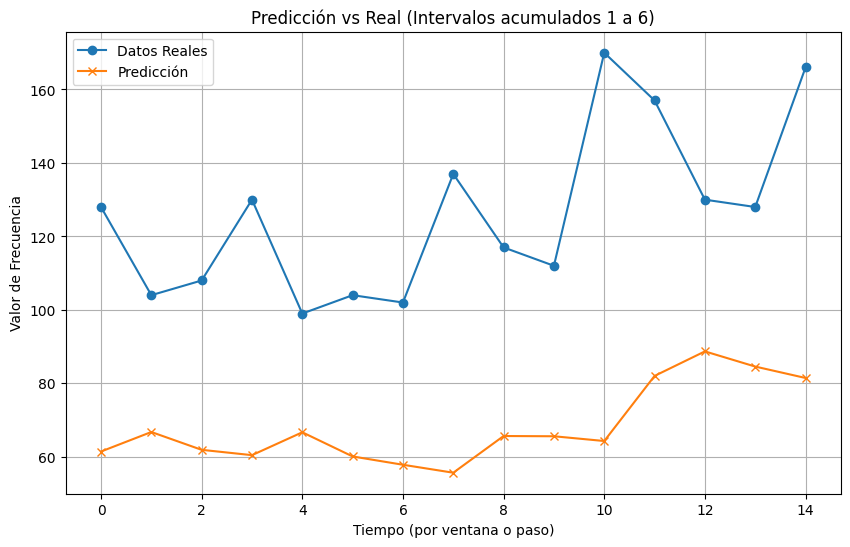

Iteración 7: Mejor época = 5, Loss = 0.0061
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 7: MAE = 34.82, MSE = 1717.63


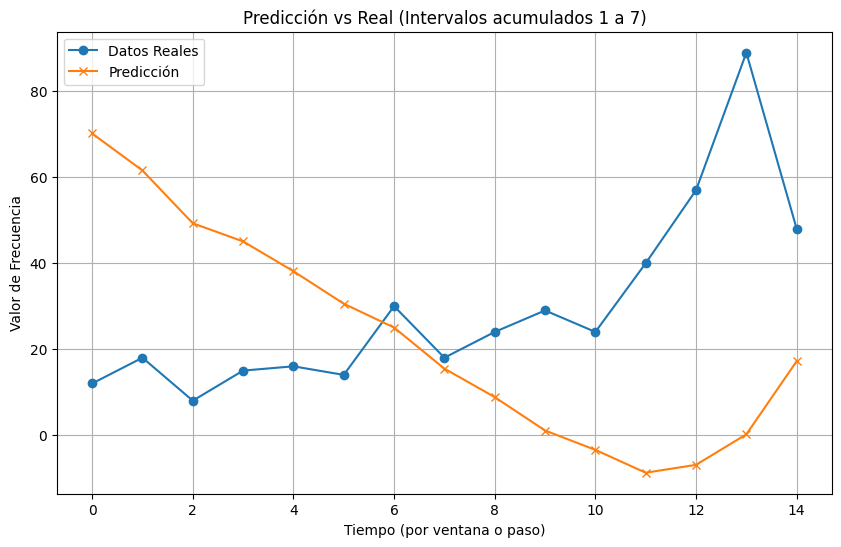

Iteración 8: Mejor época = 7, Loss = 0.0063
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 8: MAE = 79.89, MSE = 6418.48


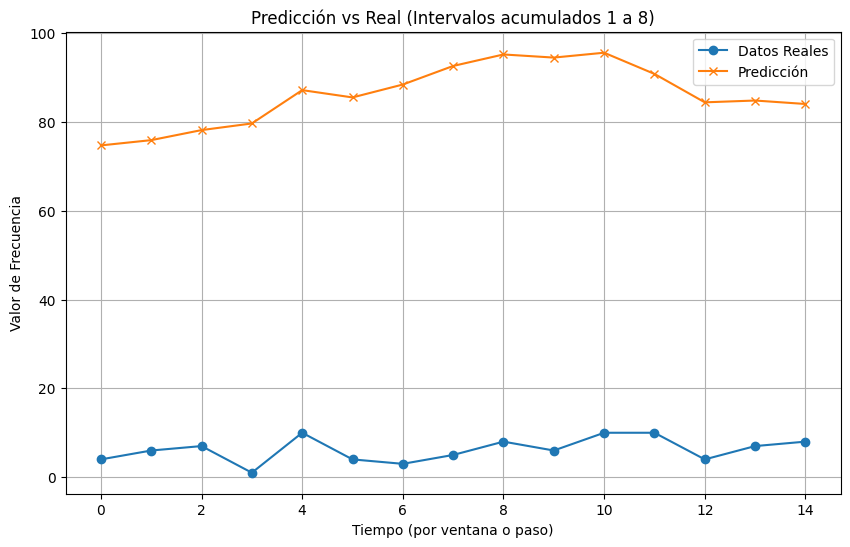


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1   83.371745   10936.032676   25.312981
1      Intervalos 1 a 2  124.771051   26252.715675   25.484056
2      Intervalos 1 a 3  307.458419  138491.165649   35.233691
3      Intervalos 1 a 4   58.917598    3800.300055  113.605232
4      Intervalos 1 a 5   58.072490    4745.629100   28.286599
5      Intervalos 1 a 6   57.923432    3775.825983   58.785470
6      Intervalos 1 a 7   34.820949    1717.625172  123.803068
7      Intervalos 1 a 8   79.889634    6418.477368  173.601149


In [6]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"14_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_6/lstm_14_15.csv', index=False)

Iteración 1: Mejor época = 12, Loss = 0.0002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Acumulando intervalos 1 a 1: MAE = 75.93, MSE = 9470.61


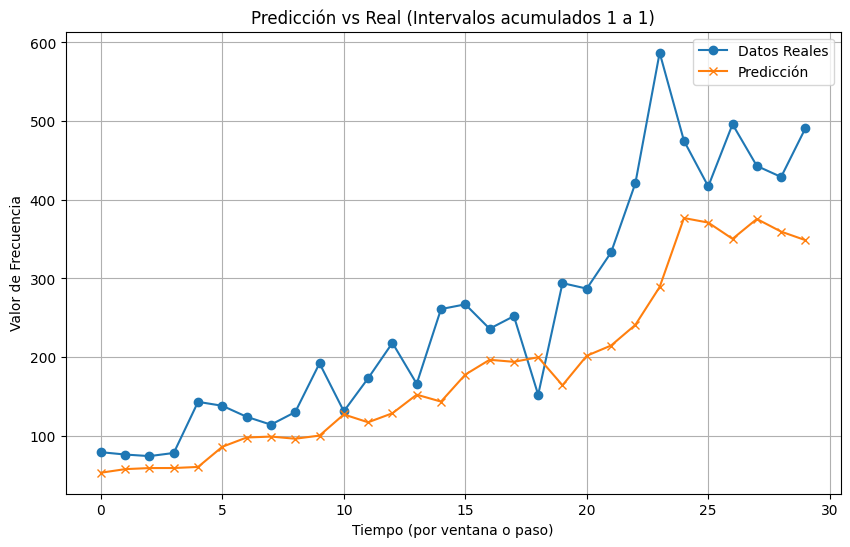

Iteración 2: Mejor época = 30, Loss = 0.0190
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 2: MAE = 92.36, MSE = 15215.31


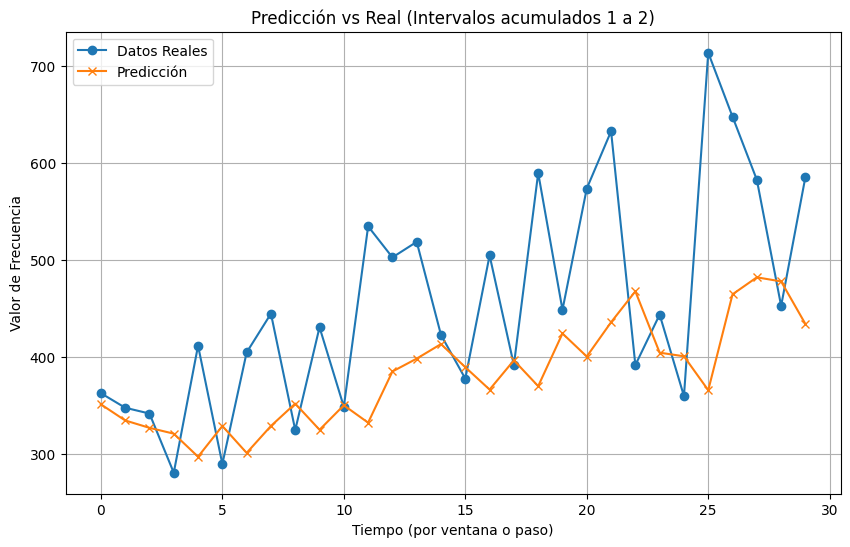

Iteración 3: Mejor época = 18, Loss = 0.0052
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 3: MAE = 244.47, MSE = 94603.95


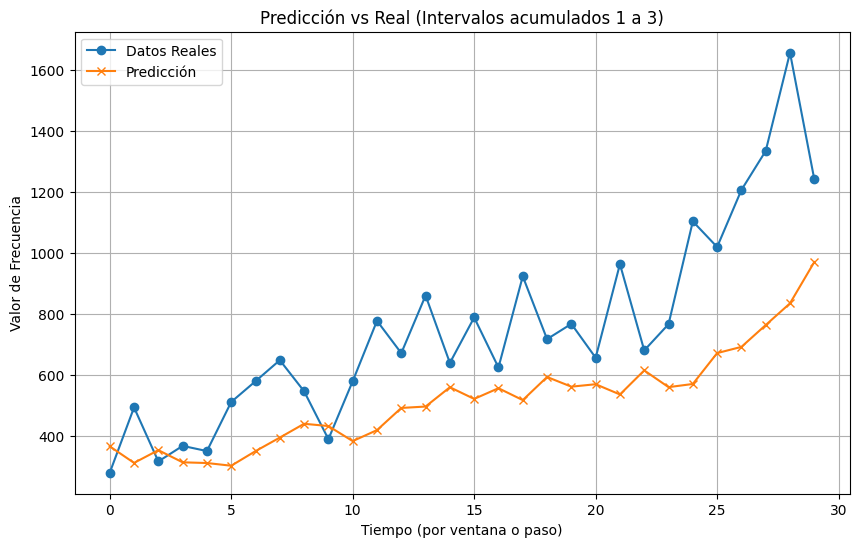

Iteración 4: Mejor época = 3, Loss = 0.0082
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 4: MAE = 35.71, MSE = 1307.69


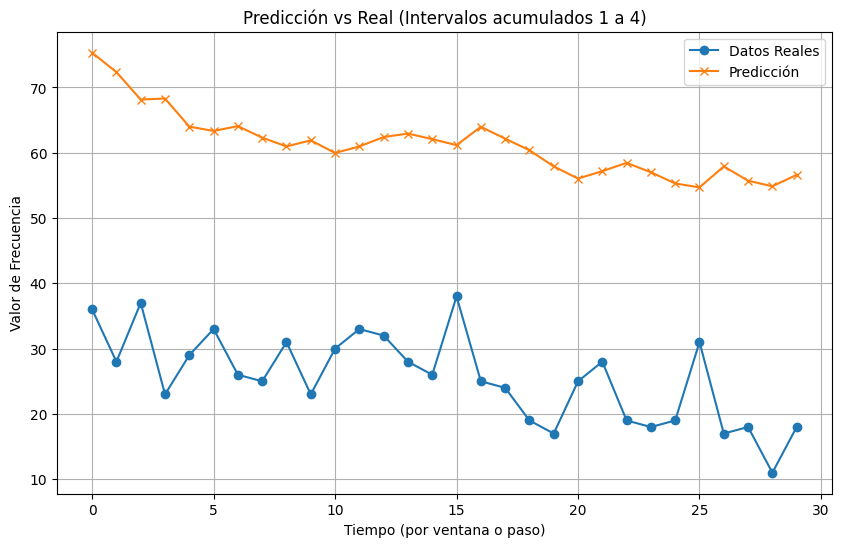

Iteración 5: Mejor época = 15, Loss = 0.0076
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 5: MAE = 78.51, MSE = 15743.51


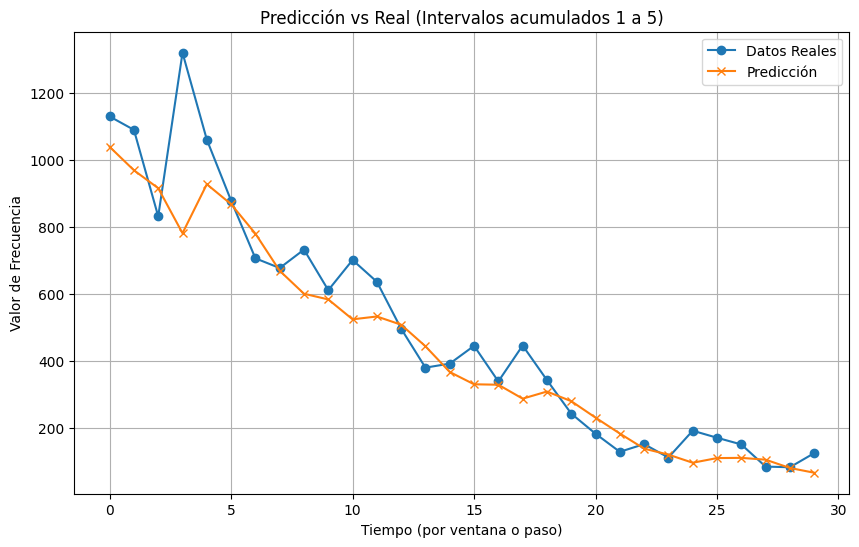

Iteración 6: Mejor época = 8, Loss = 0.0067
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 6: MAE = 19.81, MSE = 529.66


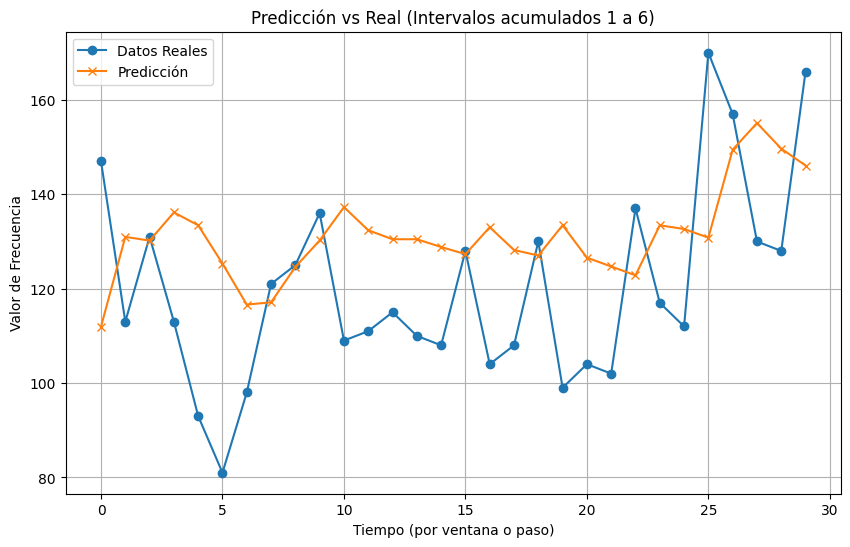

Iteración 7: Mejor época = 7, Loss = 0.0064
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 7: MAE = 36.90, MSE = 2539.18


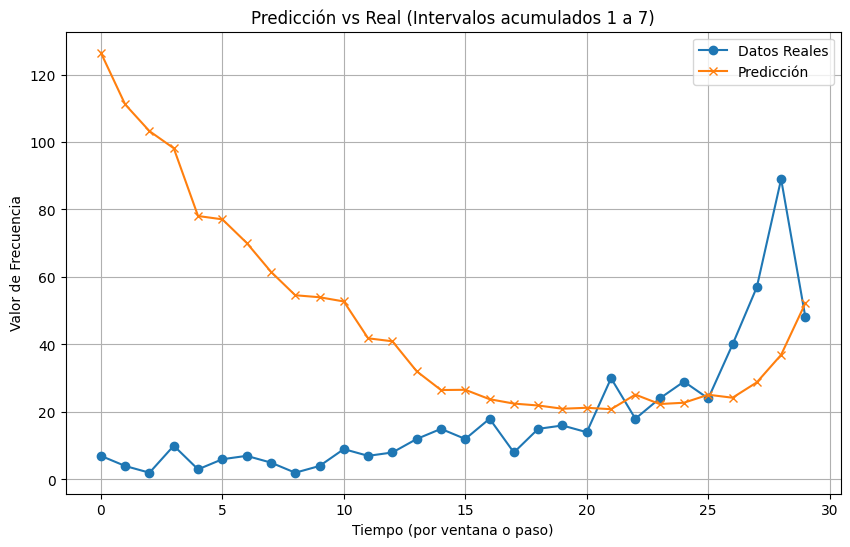

Iteración 8: Mejor época = 2, Loss = 0.0054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 8: MAE = 77.19, MSE = 7112.60


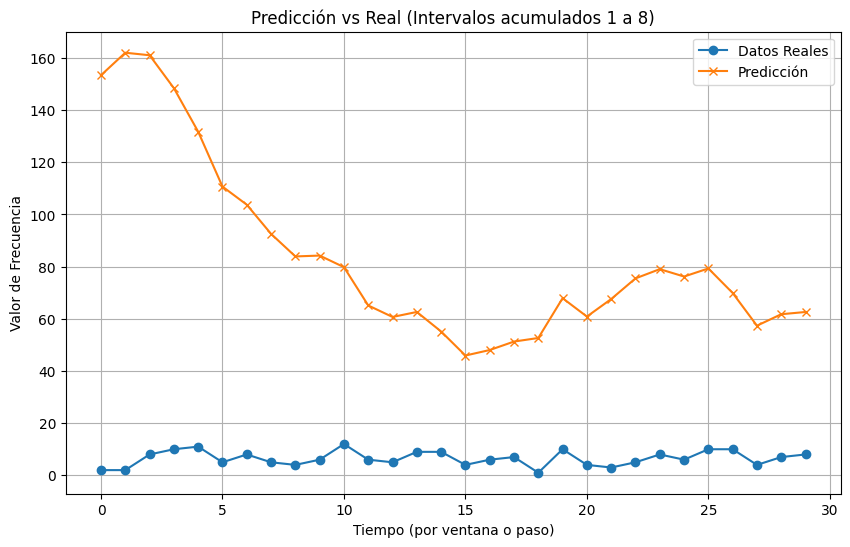


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   75.929430   9470.613958   34.790702
1      Intervalos 1 a 2   92.359918  15215.311183   20.528535
2      Intervalos 1 a 3  244.465712  94603.950518   35.483139
3      Intervalos 1 a 4   35.709223   1307.689030   84.011562
4      Intervalos 1 a 5   78.511774  15743.505750   19.982645
5      Intervalos 1 a 6   19.805173    529.658167   16.143410
6      Intervalos 1 a 7   36.902110   2539.175918   98.302923
7      Intervalos 1 a 8   77.185910   7112.597219  168.599348


In [7]:
# Parameters
WINDOW_SIZE = 14 
HORIZONTE = 30 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"14_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_6/lstm_14_30.csv', index=False)

### Train for windows size = 21


Iteración 1: Mejor época = 2, Loss = 0.0009
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Acumulando intervalos 1 a 1: MAE = 100.54, MSE = 14151.91


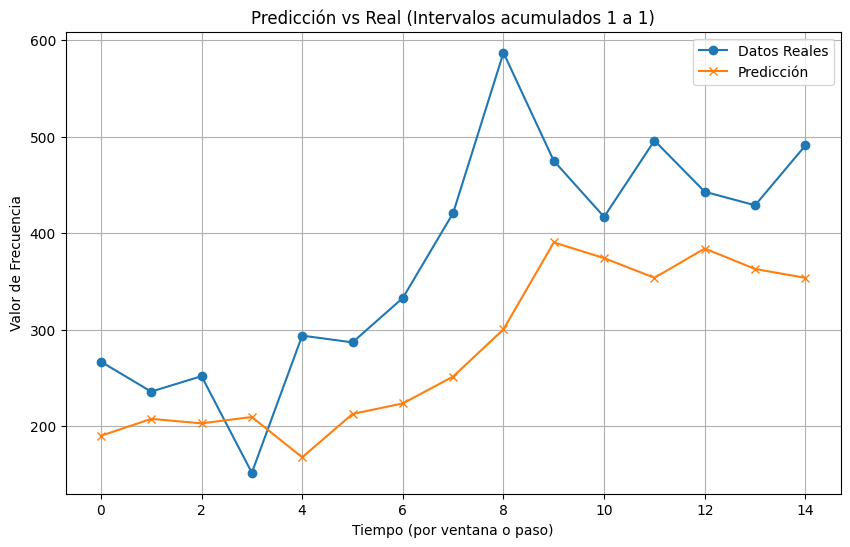

Iteración 2: Mejor época = 25, Loss = 0.0170
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Acumulando intervalos 1 a 2: MAE = 117.26, MSE = 23364.27


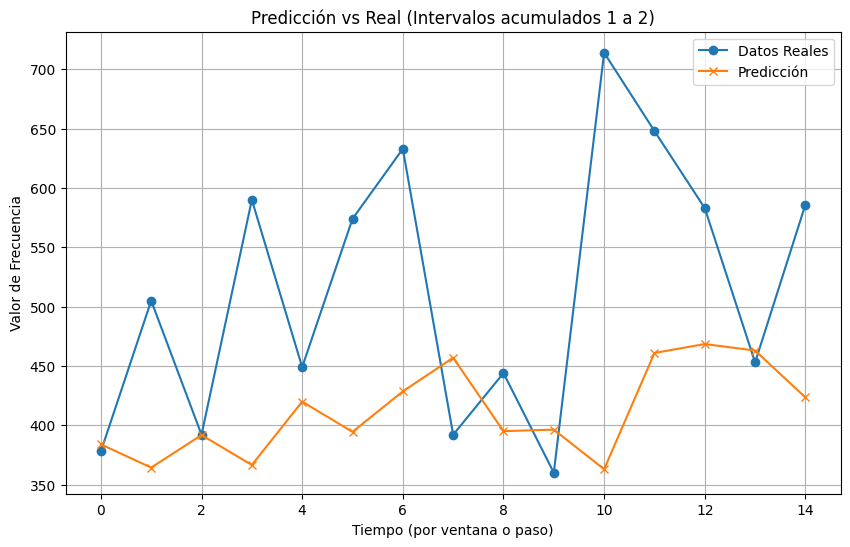

Iteración 3: Mejor época = 9, Loss = 0.0044
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Acumulando intervalos 1 a 3: MAE = 316.54, MSE = 145278.55


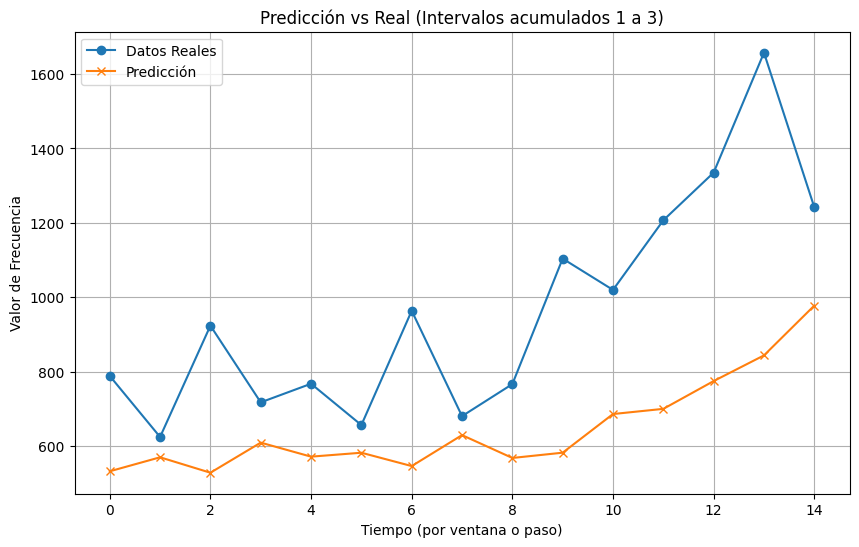

Iteración 4: Mejor época = 9, Loss = 0.0073
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 4: MAE = 20.04, MSE = 438.57


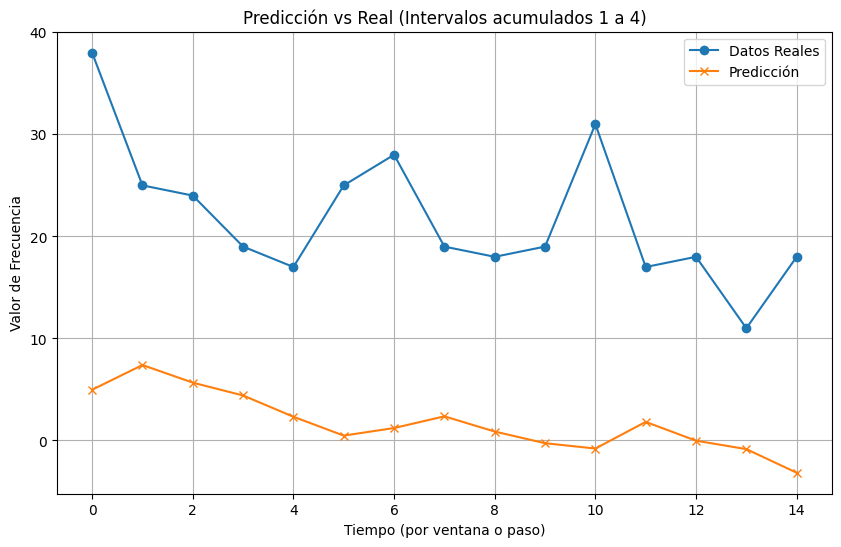

Iteración 5: Mejor época = 4, Loss = 0.0071
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Acumulando intervalos 1 a 5: MAE = 54.47, MSE = 5416.40


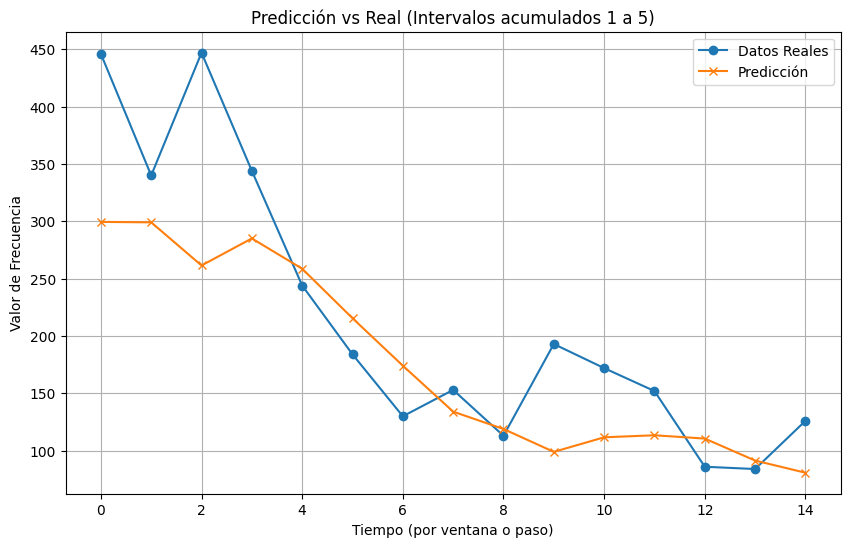

Iteración 6: Mejor época = 16, Loss = 0.0066
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 6: MAE = 19.20, MSE = 451.79


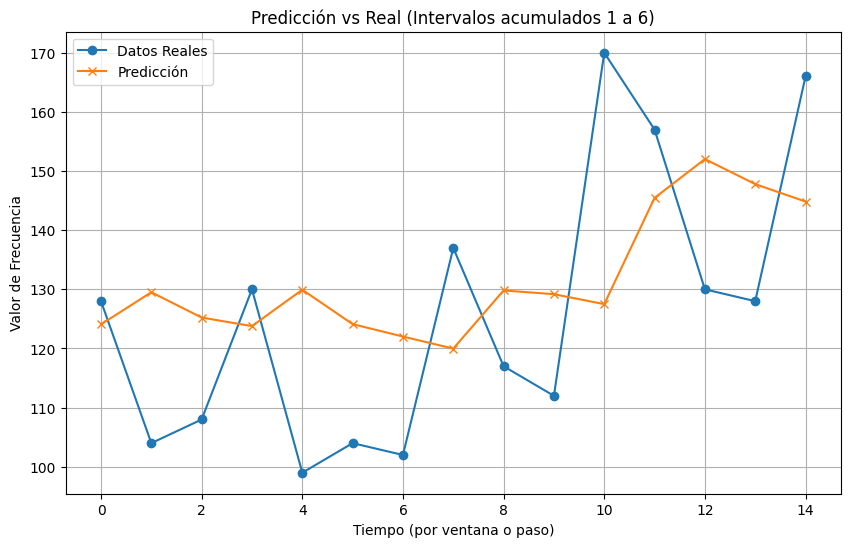

Iteración 7: Mejor época = 35, Loss = 0.0060
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Acumulando intervalos 1 a 7: MAE = 11.07, MSE = 228.80


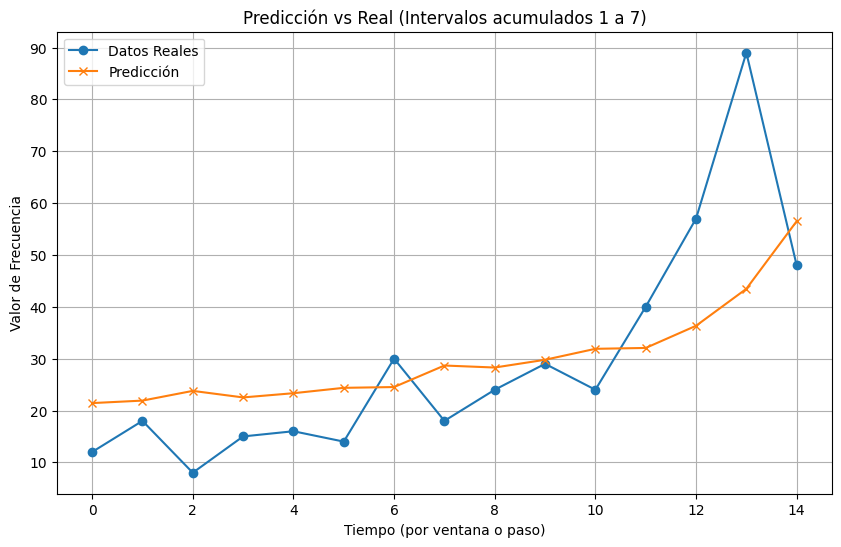

Iteración 8: Mejor época = 1, Loss = 0.0054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 8: MAE = 10.72, MSE = 122.99


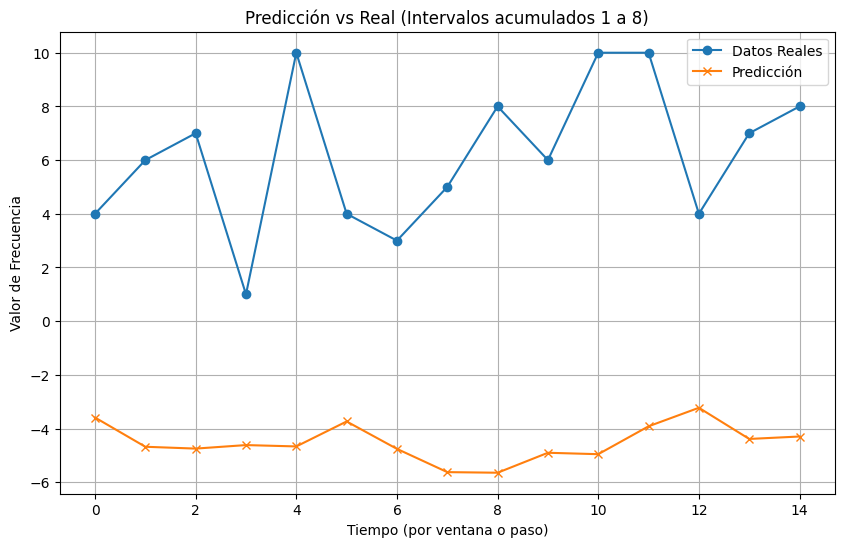


Resumen de métricas:
  Intervalos Acumulados         MAE            MSE       SMAPE
0      Intervalos 1 a 1  100.544126   14151.905964   31.013224
1      Intervalos 1 a 2  117.255302   23364.269983   23.645679
2      Intervalos 1 a 3  316.535791  145278.553818   36.548638
3      Intervalos 1 a 4   20.037021     438.570563  169.116292
4      Intervalos 1 a 5   54.471459    5416.397707   27.018634
5      Intervalos 1 a 6   19.197749     451.790650   14.988325
6      Intervalos 1 a 7   11.073282     228.795431   38.081481
7      Intervalos 1 a 8   10.716748     122.985569  200.000000


In [8]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 15 
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"21_15_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_6/lstm_21_15.csv', index=False)

Iteración 1: Mejor época = 13, Loss = 0.0002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Acumulando intervalos 1 a 1: MAE = 73.46, MSE = 9127.80


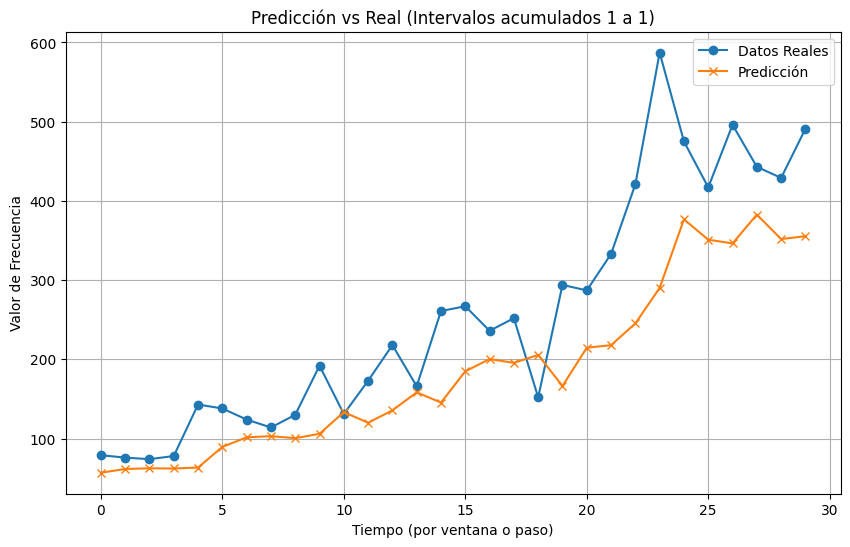

Iteración 2: Mejor época = 20, Loss = 0.0139
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 2: MAE = 98.03, MSE = 17042.18


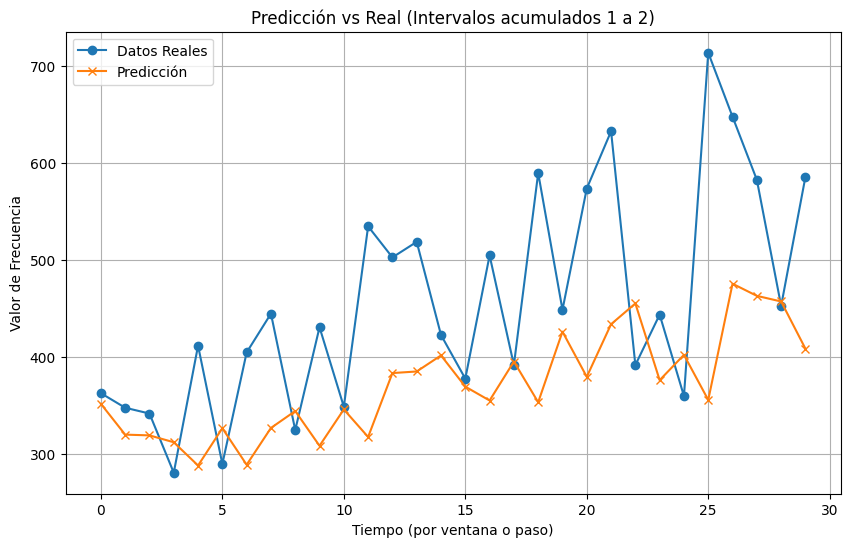

Iteración 3: Mejor época = 1, Loss = 0.0058
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 3: MAE = 215.16, MSE = 79416.07


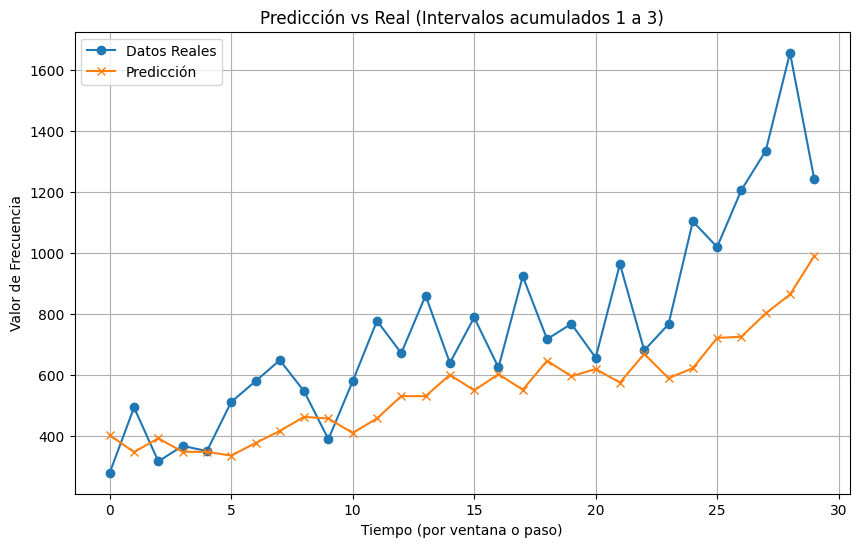

Iteración 4: Mejor época = 13, Loss = 0.0068
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 4: MAE = 7.56, MSE = 85.16


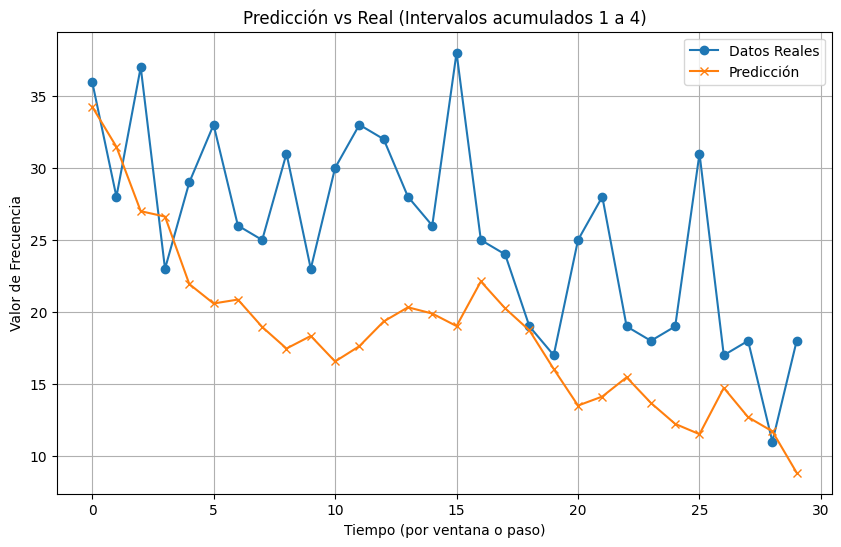

Iteración 5: Mejor época = 24, Loss = 0.0057
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Acumulando intervalos 1 a 5: MAE = 85.76, MSE = 16887.30


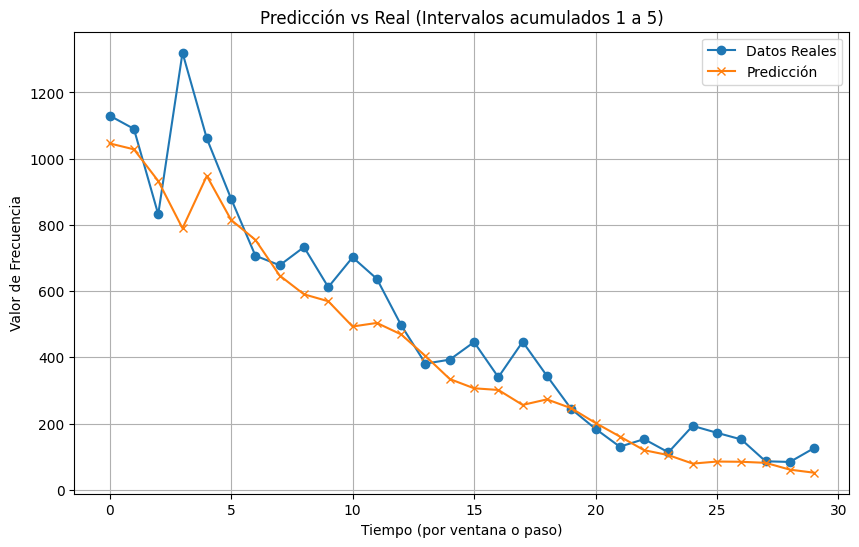

Iteración 6: Mejor época = 11, Loss = 0.0068
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Acumulando intervalos 1 a 6: MAE = 15.90, MSE = 432.44


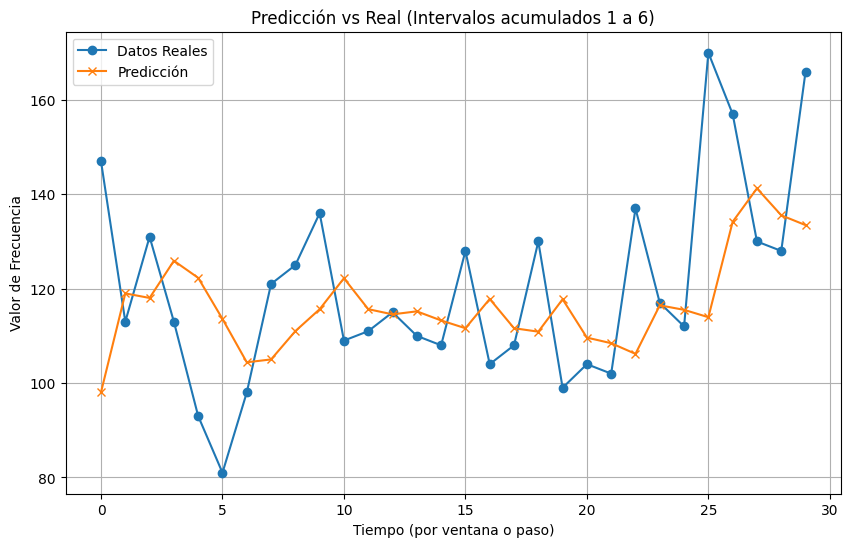

Iteración 7: Mejor época = 13, Loss = 0.0055
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Acumulando intervalos 1 a 7: MAE = 20.73, MSE = 1204.83


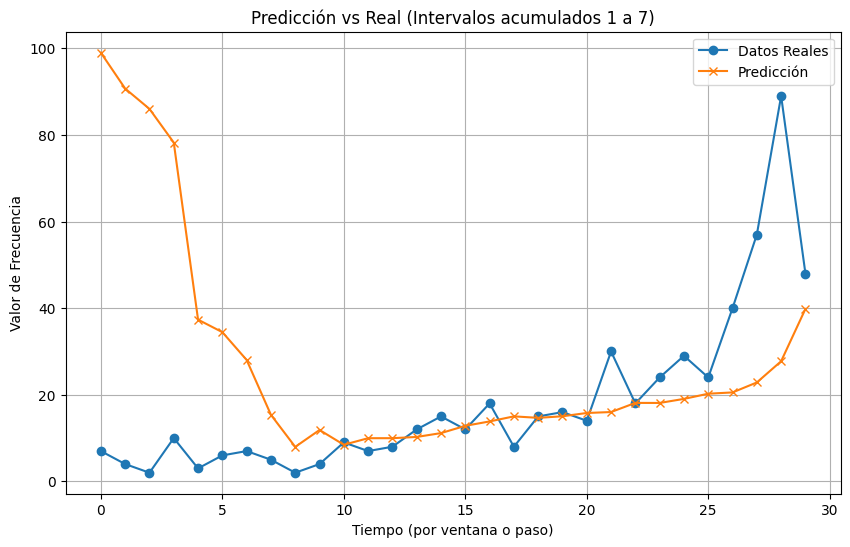

Iteración 8: Mejor época = 15, Loss = 0.0054
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Acumulando intervalos 1 a 8: MAE = 34.67, MSE = 1211.74


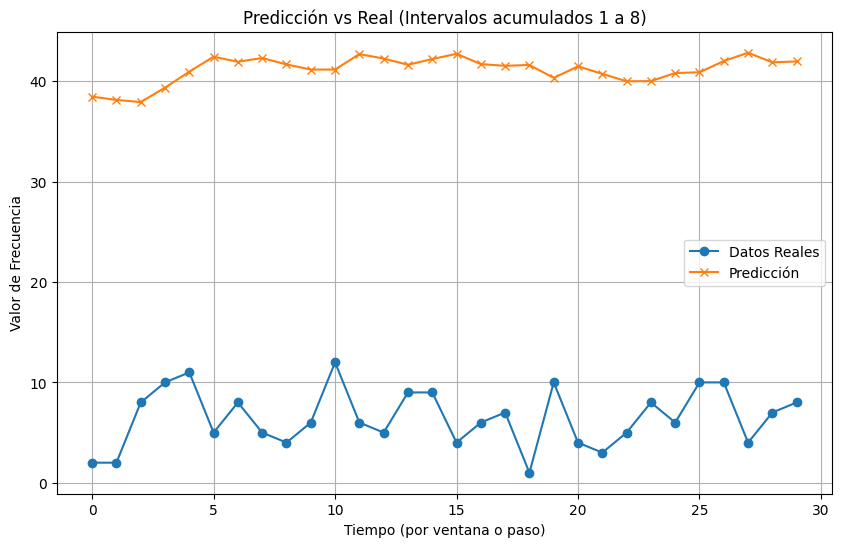


Resumen de métricas:
  Intervalos Acumulados         MAE           MSE       SMAPE
0      Intervalos 1 a 1   73.462831   9127.804127   32.277419
1      Intervalos 1 a 2   98.025020  17042.181149   22.093019
2      Intervalos 1 a 3  215.160067  79416.072739   30.185673
3      Intervalos 1 a 4    7.555167     85.164740   34.166083
4      Intervalos 1 a 5   85.755124  16887.300292   24.669720
5      Intervalos 1 a 6   15.901379    432.442047   13.154811
6      Intervalos 1 a 7   20.730608   1204.833214   69.921958
7      Intervalos 1 a 8   34.672918   1211.738084  146.681444


In [9]:
# Parameters
WINDOW_SIZE = 21 
HORIZONTE = 30
EPOCHS = 50          
BATCH_SIZE = 16     

intervalos_ordenados = create_intervals(df)

resultados = []

# Inicializamos el escalador (se ajustará en cada iteración)
scaler = MinMaxScaler(feature_range=(0, 1))

# Bucle incremental para cada acumulación de intervalos
for i in range(len(intervalos_ordenados)):
   
    # Intervalos acumulados
    intervalos_incluir = intervalos_ordenados[:i+1]
    df_train = df[df['Intervalo'].isin(intervalos_incluir)]
    

    df_train = df_train.sort_values(by='Fecha')
    
    series = df_train['Frecuencia'].values.reshape(-1, 1)
    
    # Escalamos los datos
    series_scaled = scaler.fit_transform(series)
    
    # Recordar que para generar las ventanas se requieren window_size datos previos
    if len(series_scaled) <= WINDOW_SIZE + HORIZONTE:
        print(f"Iteración {i+1}: No hay suficientes datos para formar las ventanas (se requiere al menos {WINDOW_SIZE+HORIZONTE} datos)")
        continue
    
    train_data = series_scaled[:-HORIZONTE]
    test_data = series_scaled[-(HORIZONTE + WINDOW_SIZE):]  # Incluye la ventana previa para test
    
    # Generamos las secuencias (ventanas)
    x_train, y_train = create_windows(train_data, WINDOW_SIZE)
    x_test, y_test = create_windows(test_data, WINDOW_SIZE)
    
    # Reshape para que coincida con la entrada de LSTM: (muestras, window_size, 1)
    x_train = x_train.reshape(-1, WINDOW_SIZE, 1)
    x_test = x_test.reshape(-1, WINDOW_SIZE, 1)
    
    # Construimos y entrenamos el modelo
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es_cb],
        verbose=0
    )
    
    # Se añade logica de la función de perdida
    # 1) Encuentro la época de mínima pérdida
    loss_vals = history.history['loss']
    epochs_ran = len(loss_vals) 
    best_epoch = int(np.argmin(loss_vals)) + 1         # +1 porque los epochs comienzan en 1
    best_loss = loss_vals[best_epoch-1]
    print(f"Iteración {i+1}: Mejor época = {best_epoch}, Loss = {best_loss:.4f}")

    # 2) Grafico la curva de entrenamiento y marco la mejor época
    plt.figure(figsize=(8,5))
    ax = plt.gca()  # obtenemos el eje actual
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  
    plt.plot(range(1, epochs_ran+1), loss_vals, marker='o', label='Training loss')
    plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
    plt.title(f"Pérdida durante el entrenamiento\nIntervalos 1 a {i+1}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 3) Guardo la figura en la carpeta
    plot_path = os.path.join(loss_folder, f"21_30_loss_intervalos_1_{i+1}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close() 

    
    # Hacemos la predicción para el conjunto test
    y_pred_scaled = model.predict(x_test)
    
    # Invertimos la transformación del escalador para volver a los valores originales
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    
    # Calculamos las métricas
    mae = mean_absolute_error(y_test_inv, y_pred)
    mse = mean_squared_error(y_test_inv, y_pred)
    smape_value = smape(y_test_inv, y_pred)

    resultados.append({
        'Intervalos Acumulados': f"Intervalos 1 a {i+1}",
        'MAE': mae,
        'MSE': mse,
        'SMAPE': smape_value
    })
    
    print(f"Acumulando intervalos 1 a {i+1}: MAE = {mae:.2f}, MSE = {mse:.2f}")
    
    # Graficar datos reales vs predicción para este intervalo
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inv, label="Datos Reales", marker='o')
    plt.plot(y_pred, label="Predicción", marker='x')
    plt.title(f"Predicción vs Real (Intervalos acumulados 1 a {i+1})")
    plt.xlabel("Tiempo (por ventana o paso)")
    plt.ylabel("Valor de Frecuencia")
    plt.legend()
    plt.grid(True)
    plt.show()


df_resultados = pd.DataFrame(resultados)
print("\nResumen de métricas:")
print(df_resultados) 
df_resultados.to_csv('C:/Users/criju/Documents/Codigos Tesis/resultados_6/lstm_21_30.csv', index=False)